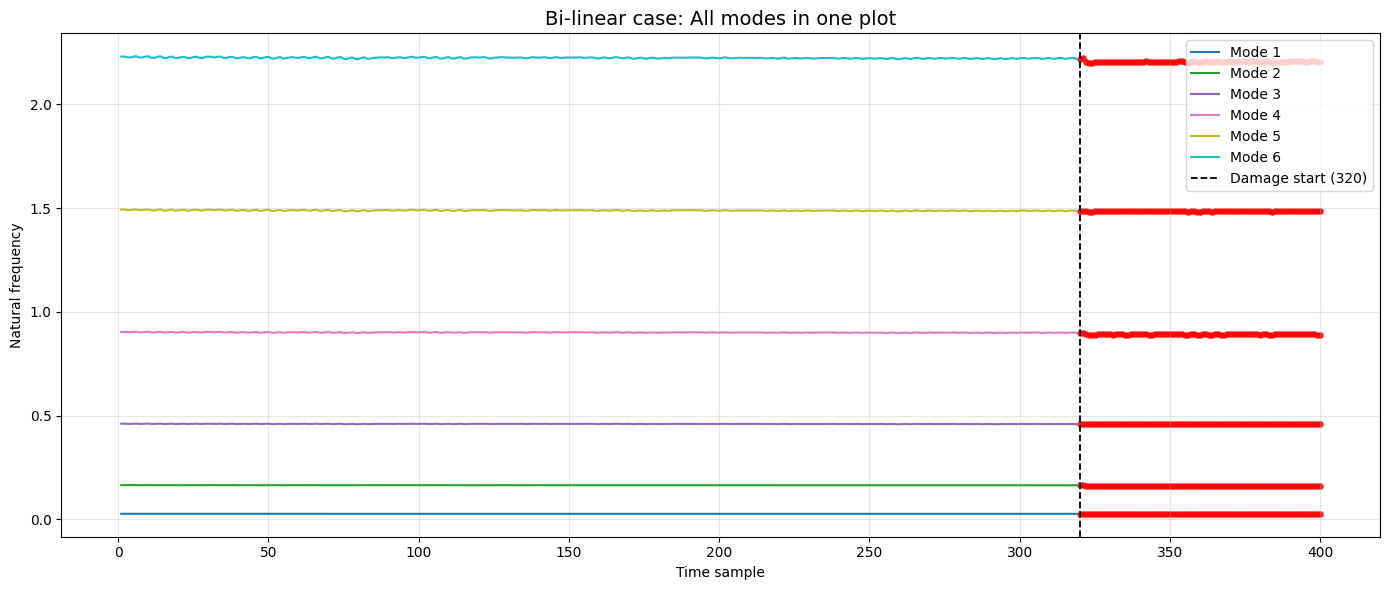

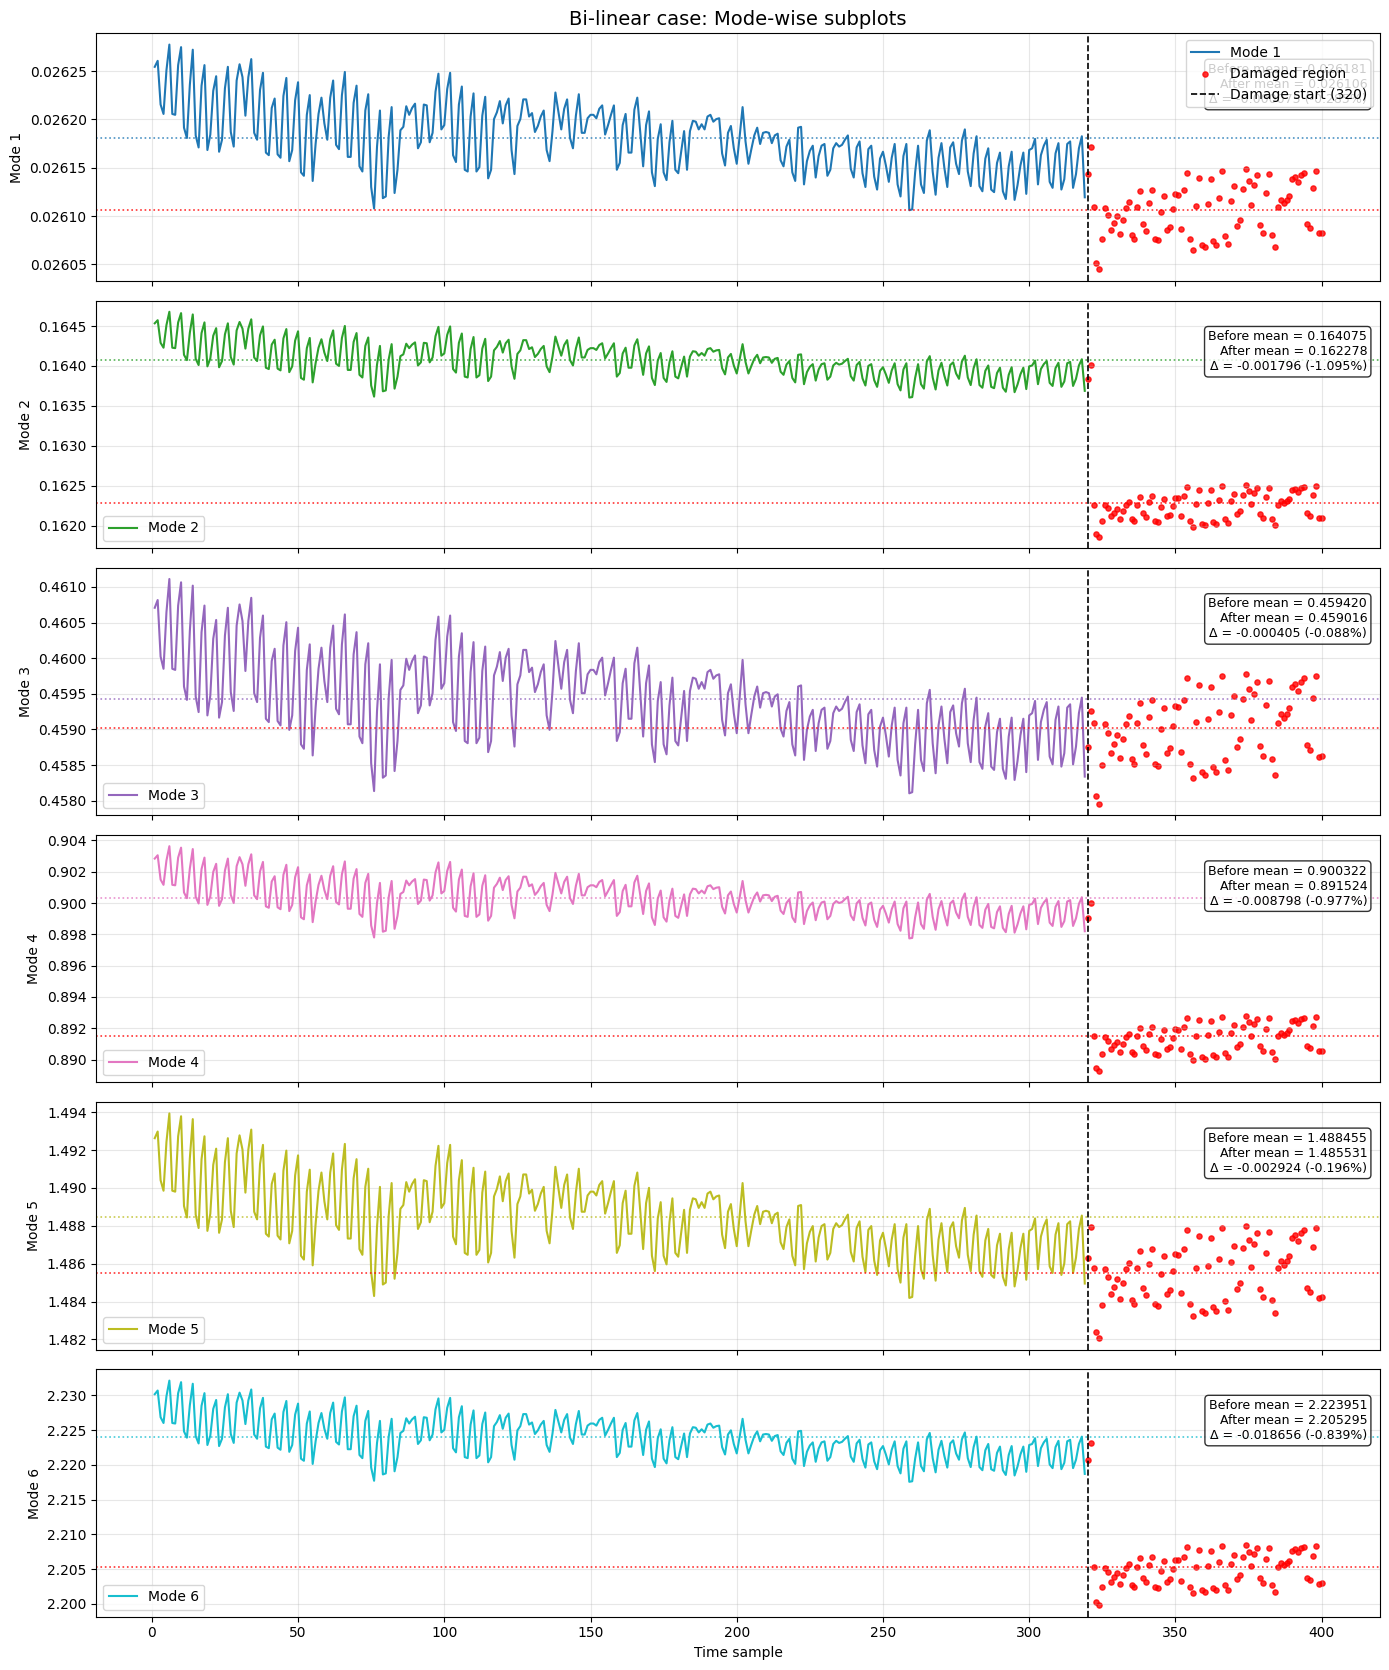

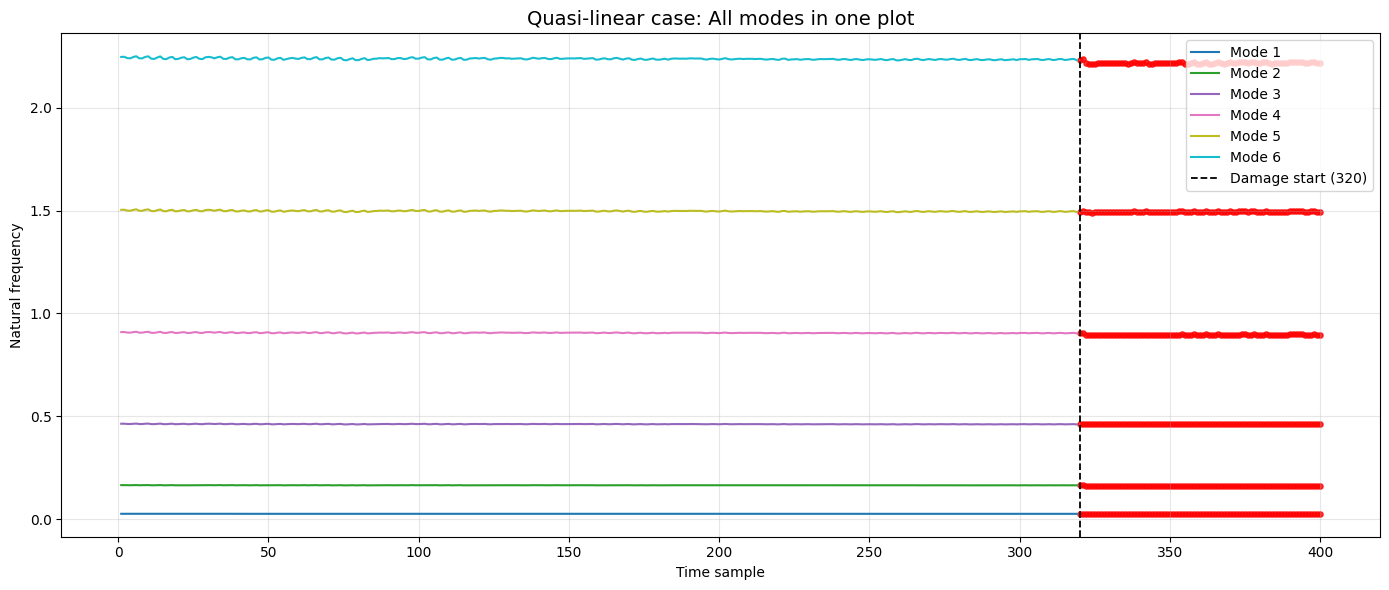

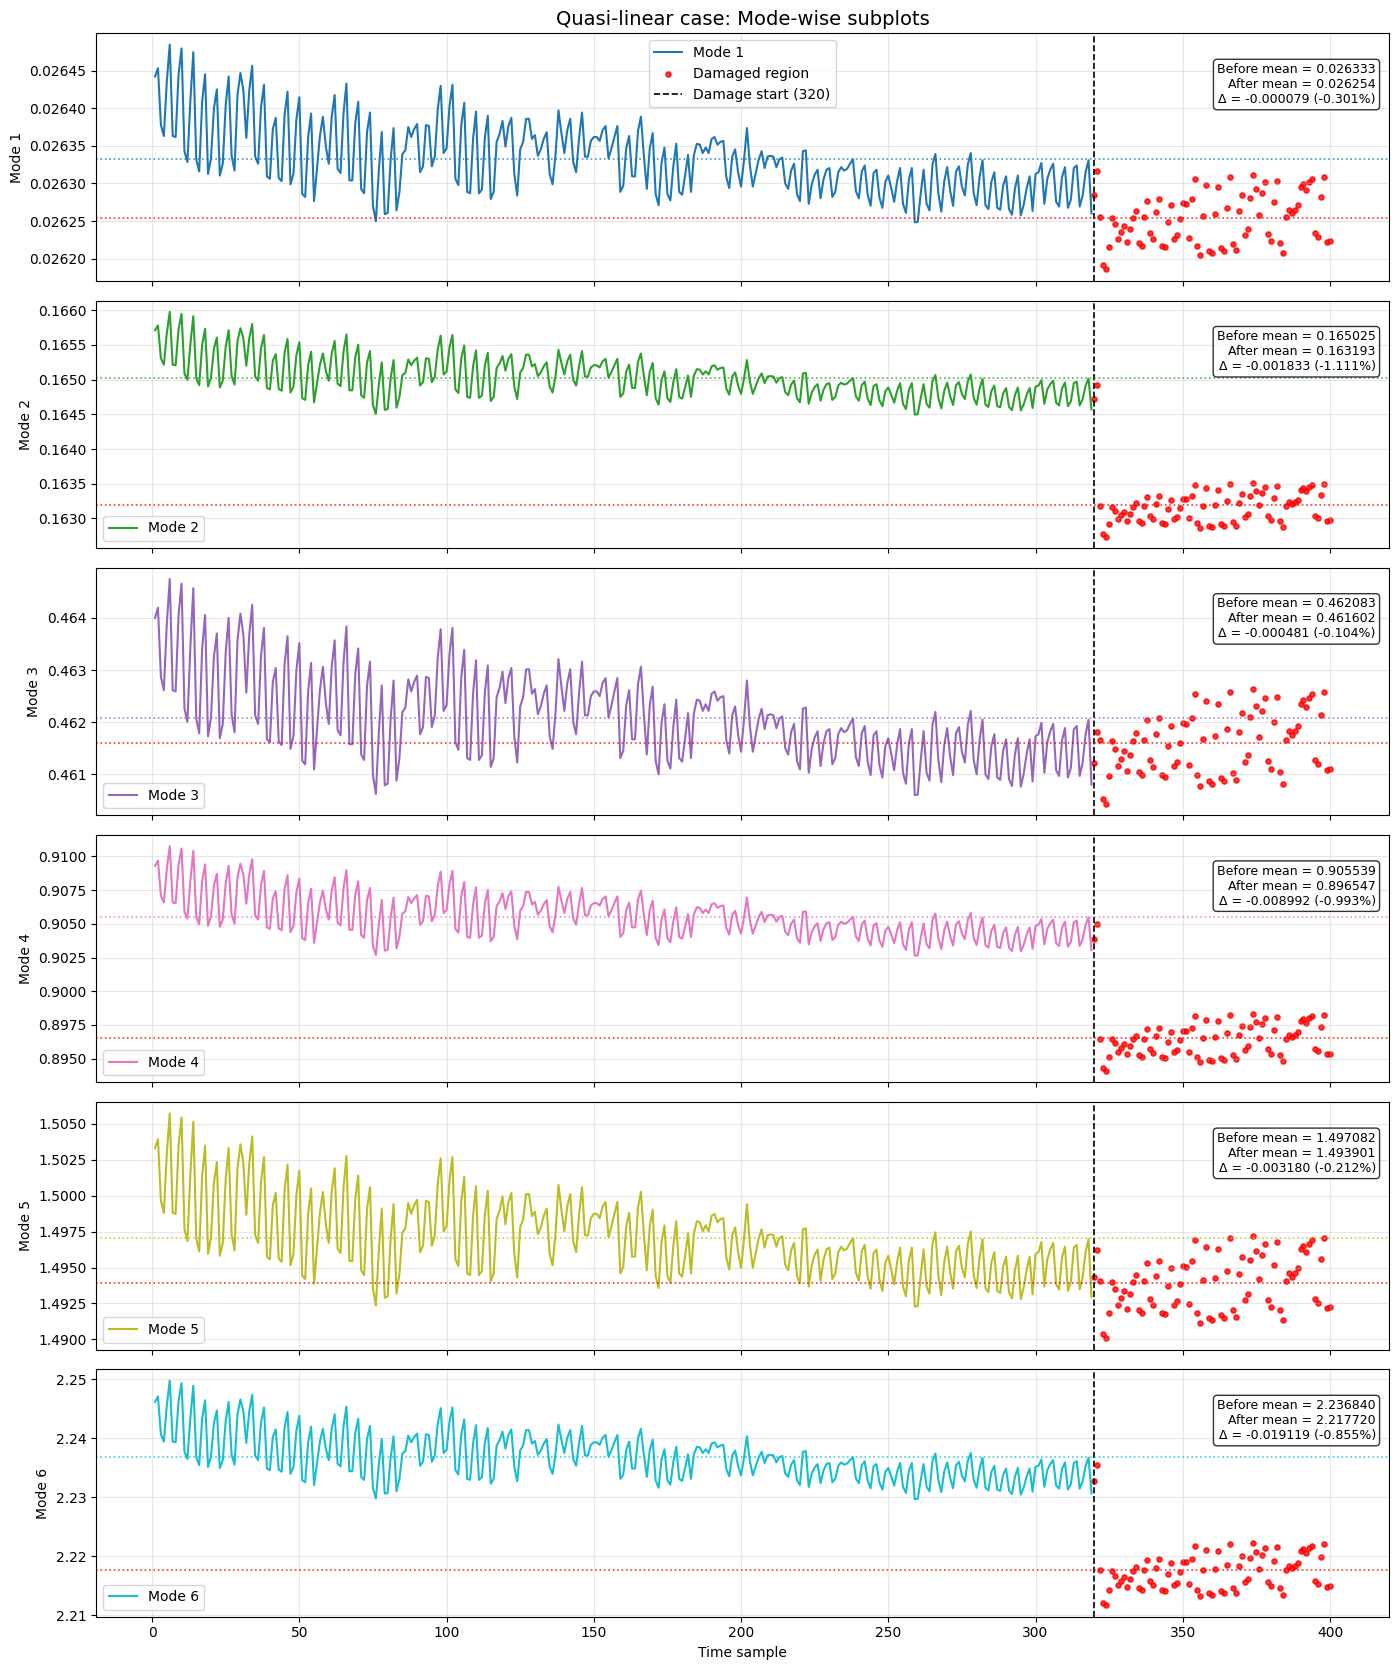

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===== 파일 경로 =====
file_bilinear = "df_result(bi-linear,0.9,6).csv"
file_quasilinear = "df_result(Quai-linear,0.9,6).csv"

# ===== CSV 읽기 =====
df_bi = pd.read_csv(file_bilinear)
df_quasi = pd.read_csv(file_quasilinear)

df_bi.columns = [str(c) for c in df_bi.columns]
df_quasi.columns = [str(c) for c in df_quasi.columns]

damage_start = 320

# ===== 공통 플로팅 함수 =====
def plot_combined_and_subplots(df, title_prefix, damage_start=320):
    x = np.arange(1, len(df) + 1)
    n_modes = df.shape[1]
    colors = plt.cm.tab10(np.linspace(0, 1, n_modes))

    mask_before = x < damage_start
    mask_after = x >= damage_start

    # --------------------------------------------------
    # Figure 1: 모든 모드를 한 플롯에 표시
    # --------------------------------------------------
    plt.figure(figsize=(14, 6))

    for i, col in enumerate(df.columns):
        y = df[col].values

        plt.plot(
            x[mask_before],
            y[mask_before],
            color=colors[i],
            linewidth=1.5,
            label=f"Mode {i+1}"
        )

        plt.scatter(
            x[mask_after],
            y[mask_after],
            color='red',
            s=14,
            alpha=0.8
        )

    plt.axvline(
        x=damage_start,
        color='black',
        linestyle='--',
        linewidth=1.3,
        label=f'Damage start ({damage_start})'
    )

    plt.title(f"{title_prefix}: All modes in one plot", fontsize=14)
    plt.xlabel("Time sample")
    plt.ylabel("Natural frequency")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # Figure 2: 모드별 subplot을 한 figure에 표시
    # --------------------------------------------------
    fig, axes = plt.subplots(n_modes, 1, figsize=(14, 2.8 * n_modes), sharex=True)

    if n_modes == 1:
        axes = [axes]

    for i, col in enumerate(df.columns):
        y = df[col].values
        ax = axes[i]

        # 손상 전
        ax.plot(
            x[mask_before],
            y[mask_before],
            color=colors[i],
            linewidth=1.5,
            label=f"Mode {i+1}"
        )

        # 손상 후
        ax.scatter(
            x[mask_after],
            y[mask_after],
            color='red',
            s=14,
            alpha=0.8,
            label='Damaged region' if i == 0 else None
        )

        # 손상 시작선
        ax.axvline(
            x=damage_start,
            color='black',
            linestyle='--',
            linewidth=1.2,
            label=f'Damage start ({damage_start})' if i == 0 else None
        )

        # 손상 전/후 평균선
        mean_before = np.mean(y[mask_before])
        mean_after = np.mean(y[mask_after])

        ax.axhline(
            mean_before,
            color=colors[i],
            linestyle=':',
            linewidth=1.2,
            alpha=0.8
        )
        ax.axhline(
            mean_after,
            color='red',
            linestyle=':',
            linewidth=1.2,
            alpha=0.8
        )

        # 평균값 텍스트
        drop = mean_after - mean_before
        drop_pct = (drop / mean_before) * 100

        ax.text(
            0.99, 0.88,
            f"Before mean = {mean_before:.6f}\nAfter mean = {mean_after:.6f}\nΔ = {drop:.6f} ({drop_pct:.3f}%)",
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

        ax.set_ylabel(f"Mode {i+1}")
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')

    axes[0].set_title(f"{title_prefix}: Mode-wise subplots", fontsize=14)
    axes[-1].set_xlabel("Time sample")

    plt.tight_layout()
    plt.show()


# ===== 실행 =====
plot_combined_and_subplots(df_bi, "Bi-linear case", damage_start=320)
plot_combined_and_subplots(df_quasi, "Quasi-linear case", damage_start=320)
